# Implementation

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# from validation_and_helpers import load_run
from non_markov_E_in_eigener_file import calculate_heom_propagator, _make_solver
from non_markov_circuit import propagate_memory_shots, propagate_memory_density_matrix, propagate_memory_classical

# Parameter

In [9]:
# ---- physical constants (energies in cm^-1, time tau = 2*pi*c*t in cm) ----
_C_CM = 2.99792458e10                    # speed of light [cm/s]
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM     # tau[cm] per t[fs]
KB_CM = 0.6950348004                     # Boltzmann constant [cm^-1/K]

N = 4                                    # 4-site (Seneviratne eq. 30) or 7-site FMO

if N == 4:
    H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                      [-87.7, 12495.0,  30.8,   8.2],
                      [5.5,      30.8, 12175.0, -53.4],
                      [-5.9,      8.2, -53.4, 12285.0]])
elif N == 7:
    H_FMO = np.array([[1410.0, -87.7, 5.5, -5.9, 6.7, -13.7, -9.9],
                      [-87.7, 1530.0, 30.8, 8.2, 0.7, 11.8, 4.3],
                      [5.5, 30.8, 1210.0, -53.5, -2.2, -9.6, 6.0],
                      [-5.9, 8.2, -53.5, 1320.0, -70.7, -17.0, -63.3],
                      [6.7, 0.7, -2.2, -70.7, 1480.0, 81.1, -1.3],
                      [-13.7, 11.8, -9.6, -17.0, 81.1, 1630.0, 39.7],
                      [-9.9, 4.3, 6.0, -63.3, -1.3, 39.7, 1440.0]])
else:
    raise ValueError('N must be 4 or 7')

H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)
LAM_FMO, GAM_FMO, T_FMO = 3.0, 80, 300.0

# Bundled once and splatted into every method below, so HEOM and Lindblad are
# guaranteed to run on identical parameters.
MODEL = dict(H=H_FMO, lam=LAM_FMO, gamma=GAM_FMO, T_K=T_FMO,
             KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)

K = 25
N = 4 
dt_fs = 1
t_fs = np.arange(0.0, 1001.0, dt_fs)      
HEOM_depth = 3

In [10]:
# Initialisiere globales Dictionary (falls noch nicht vorhanden)
if 'out_B' not in globals():
    out_B = {}

M_KRYLOV = 32

# Calculate

### Startzustände

In [11]:
# 1. Propagator E und die berechneten Kurzzeit-Karten holen
E, K, maps = calculate_heom_propagator(dt_fs, HEOM_depth=HEOM_depth, K_heom=K, N=N, **MODEL)

# 2. Vektorisierter Startzustand rho(0)
rho0_vec = np.zeros(N * N, complex)
rho0_vec[0] = 1.0  # Anregung auf Site 1

# 3. Exakte Historie der ersten K Schritte via L(t) * rho0 berechnen
rho_history = [maps[i] @ rho0_vec for i in range(K)]

# 4. Physikalischen Super-Vektor X0 zusammensetzen:
# rho(t_{K-1}) liegt ganz oben (Index 0), rho(t_0) ganz unten
X0 = np.concatenate(rho_history[::-1])

### Exaktes Ergebnis mit qutip

In [12]:
import qutip as qt
import time

# 1. Startzustand als QuTiP Qobj definieren (Anregung auf Site 1)
rho0_qt = qt.Qobj(np.diag([1.0] + [0.0] * (N - 1)))

# 2. Zeitachse in die physikalischen Einheiten (cm) umwandeln, die der Solver nutzt
t_cm = t_fs * MODEL['FS_TO_CM']

print("Starte exakte QuTiP HEOM Propagation")
start_time = time.time()

# 3. Solver instanziieren (nutzt deine bereits vorhandene Funktion)
solver = _make_solver(H=MODEL['H'], lam=MODEL['lam'], gamma=MODEL['gamma'], 
                      T_K=MODEL['T_K'], KB_CM=MODEL['KB_CM'], Nk=1, depth=HEOM_depth)

# 4. Solver über die gesamte Zeitachse ausführen
result = solver.run(rho0_qt, t_cm)

# 5. Populationen (Diagonalelemente) extrahieren
pops_qutip = np.zeros((len(t_fs), N))
for i, state in enumerate(result.states):
    pops_qutip[i, :] = np.real(state.diag())
    
print(f"QuTiP Propagation abgeschlossen in {time.time() - start_time:.2f} Sekunden.")

# In das globale Dictionary einspeichern
# (Wir übergeben None für qc und info, da dies eine rein klassische Referenz ist)
out_B['HEOM (QuTiP Direct)'] = (pops_qutip, None, None)

Starte exakte QuTiP HEOM Propagation
10.0%. Run time:   0.04s. Est. time left: 00:00:00:00
20.0%. Run time:   0.07s. Est. time left: 00:00:00:00
30.0%. Run time:   0.10s. Est. time left: 00:00:00:00
40.0%. Run time:   0.13s. Est. time left: 00:00:00:00
50.0%. Run time:   0.16s. Est. time left: 00:00:00:00
60.0%. Run time:   0.19s. Est. time left: 00:00:00:00
70.0%. Run time:   0.23s. Est. time left: 00:00:00:00
80.0%. Run time:   0.26s. Est. time left: 00:00:00:00
90.0%. Run time:   0.29s. Est. time left: 00:00:00:00
100.0%. Run time:   0.32s. Est. time left: 00:00:00:00
Total run time:   0.32s
QuTiP Propagation abgeschlossen in 0.35 Sekunden.


### Exaktes Ergebnis aber mit Fensterlänge K

In [13]:
D_dim = N * N
n_steps_total = len(t_fs) - 1
exact_pops = np.zeros((n_steps_total + 1, N))

# Die ersten K Schritte (0 bis K-1) direkt aus der berechneten Historie befüllen:
for i in range(K):
    exact_pops[i, :] = np.real(np.diag(rho_history[i].reshape((N, N), order='F')))

# Ab Schritt K propagieren wir den Zustand klassisch mit E weiter:
X_curr = X0.copy()
for t in range(K, n_steps_total + 1):
    X_curr = E @ X_curr
    exact_pops[t, :] = np.real(np.diag(X_curr[:D_dim].reshape((N, N), order='F')))

res = {
    'HEOM': {
        'E': E,
        'K': K,
        'pops': exact_pops,
        'rho': [r.reshape((N, N), order='F') for r in rho_history]
    }
}
print("Referenz von t=0 bis t=1000 fs vollständig aufgebaut!")

Referenz von t=0 bis t=1000 fs vollständig aufgebaut!


### Shots

In [14]:
if __name__ == '__main__':
      name = 'HEOM'

      pops, qc, info = propagate_memory_shots(E, X0, len(t_fs) - K, M_KRYLOV, N)
      out_B[name] = (pops, qc, info)

      full_reg = E.shape[0]
      print(f"{name:14s} register {full_reg} -> {info['m']} (Krylov), {info['n_qubits']} qubits, depth {qc.depth()}")
      print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, p_success = {info['p_success']:.3e} ({1 / info['p_success']:.1f} shots/sample), "
            f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
      print(f"{'':14s} vs stored result: {np.abs(pops - res[name]['pops'][K - 1:]).max():.2e}\n")

KeyboardInterrupt: 

### Density Matrix

In [ ]:
if __name__ == '__main__':
      source_name = 'HEOM'
      entry_name = 'HEOM (DM)'


      # 2. Den echten physikalischen Super-Vektor X0 aufbauen
      rho0_vec = np.zeros(N * N, complex)
      rho0_vec[0] = 1.0  # Anregung startet auf Site 1

      # Die echten Zustände der ersten K Schritte berechnen
      rho_history = [maps[i] @ rho0_vec for i in range(K)]

      # Zum Vektor X0 zusammensetzen (ältester Zustand unten)
      X0 = np.concatenate(rho_history[::-1])

      # 3. Aufruf der deterministischen Dichtematrix-Funktion mit dem KORREKTEN X0
      pops, qc, info = propagate_memory_density_matrix(E, X0, len(t_fs) - K, M_KRYLOV, N)
      out_B[entry_name] = (pops, qc, info)

      full_reg = E.shape[0]
      print(f"{entry_name:14s} register {full_reg} -> {info['m']} (Krylov), {info['n_qubits']} qubits, depth {qc.depth()}")
      print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, p_success = {info.get('p_success', 1.0):.3e} ({1 / info.get('p_success', 1.0):.1f} shots/sample), "
            f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
      print(f"{'':14s} vs stored result: {np.abs(pops - res[source_name]['pops'][K - 1:]).max():.2e}\n")

### Klassisch

In [15]:
entry_name = 'HEOM (Classical Krylov)'

# Aufruf
pops_class, _, info_class = propagate_memory_classical(E, X0, len(t_fs) - K, M_KRYLOV, N)
out_B[entry_name] = (pops_class, None, info_class)

# Vergleich mit der gespeicherten Referenz
print(f"Max Abweichung zur Referenz: {np.abs(pops_class - res['HEOM']['pops'][K - 1:]).max():.2e}")
print(f"Max Abweichung zur Referenz (ab t_{{K-1}}): {np.abs(pops_qutip[K - 1:] - res['HEOM']['pops'][K - 1:]).max():.2e}")

Max Abweichung zur Referenz: 3.67e-01
Max Abweichung zur Referenz (ab t_{K-1}): 1.21e-01


# Plotting

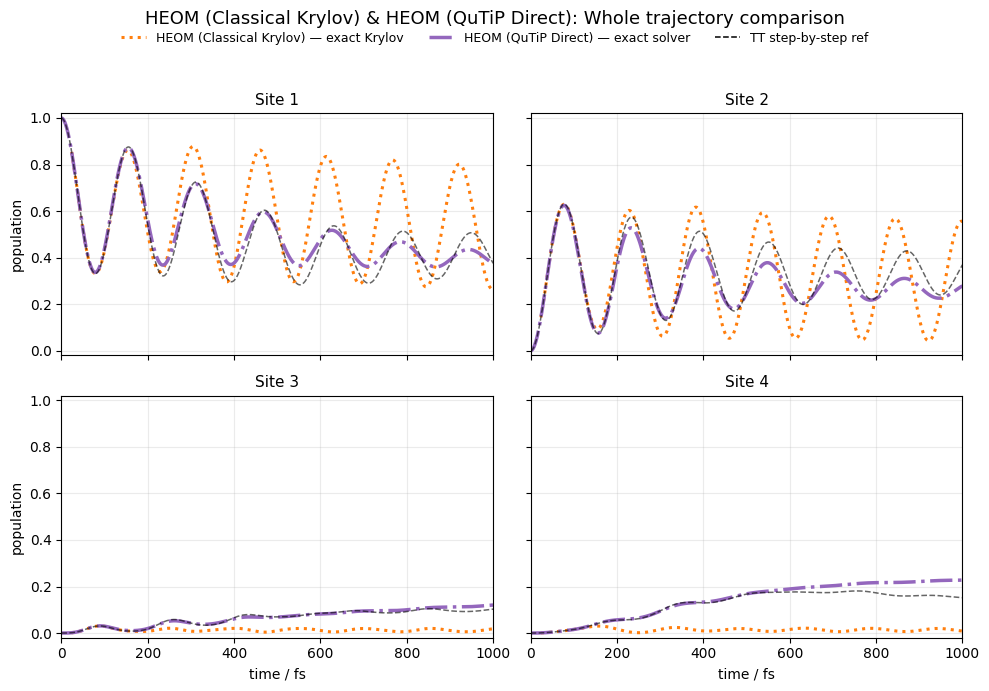

In [18]:

if __name__ == '__main__':
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    # --- AUSWAHL: Einfach gewünschte Methoden ein-/auskommentieren ---
    plot_methods = [
        #'HEOM',
        #'HEOM (DM)',
        'HEOM (Classical Krylov)',
        'HEOM (QuTiP Direct)',  # <-- Die neue direkte QuTiP Lösung
        # 'Path integral',
    ]

    # Farb-Mapping
    col = {
        'HEOM': '#1f77b4',
        'HEOM (DM)': '#2ca02c',
        'HEOM (Classical Krylov)': '#ff7f0e',
        'HEOM (QuTiP Direct)': '#9467bd',  # Lila für die exakte QuTiP Lösung
        'Path integral': '#d62728'
    }

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

    for site, ax in enumerate(axes.flat):
        for name in plot_methods:
            if name not in out_B:
                continue
            
            # Basis-Name für Referenzdaten ermitteln
            ref_key = 'HEOM' if 'HEOM' in name else 'Path integral'
            K = res[ref_key]['K']
            
            pops_data = out_B[name][0]
            
            # AUTOMATISCHE ZEITACHSEN-ANPASSUNG
            # Wenn es eine Krylov/Quanten-Methode ist (startet erst ab K-1)
            if len(pops_data) == len(t_fs) - K + 1:
                t_plot = t_fs[K - 1:]
            # Wenn es die volle QuTiP-Trajektorie ist (startet bei t=0)
            else:
                t_plot = t_fs
            
            # Stil-Unterscheidung je nach Methode
            if 'QuTiP Direct' in name:
                ax.plot(t_plot, pops_data[:, site], color=col[name], 
                        ls='-.', lw=2.5, label=name)
            elif '(DM)' in name:
                ax.plot(t_plot, pops_data[:, site], color=col[name], 
                        ls='-', lw=2.0, label=name)
            elif 'Classical' in name:
                ax.plot(t_plot, pops_data[:, site], color=col[name], 
                        ls=':', lw=2.2, label=name)
            else:
                ax.plot(t_plot, pops_data[:, site], color=col[name], 
                        marker='o', ls='none', markersize=3.5, label=name)
            
        # Zugehörige Transfer-Tensor-Referenz (schwarze gestrichelte Linie)
        ax.plot(t_fs, res['HEOM']['pops'][:, site], color='k', ls='--', lw=1.1, alpha=0.6)
            
        ax.set_title(f'Site {site + 1}', fontsize=11)
        ax.set_xlim(0, t_fs[-1])
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.25)
        if site >= 2: 
            ax.set_xlabel('time / fs')
        if site % 2 == 0: 
            ax.set_ylabel('population')

    # Dynamische Legende aufbauen
    handles = []
    for name in plot_methods:
        if name in out_B:
            if 'QuTiP Direct' in name:
                handles.append(Line2D([], [], color=col[name], ls='-.', lw=2.5, 
                                    label=f'{name} — exact solver'))
            elif '(DM)' in name:
                handles.append(Line2D([], [], color=col[name], ls='-', lw=2.0, 
                                    label=f'{name} — circuit'))
            elif 'Classical' in name:
                handles.append(Line2D([], [], color=col[name], ls=':', lw=2.2, 
                                    label=f'{name} — exact Krylov'))
            else:
                handles.append(Line2D([], [], color=col[name], marker='o', ls='none', markersize=5, 
                                    label=f'{name} — shots'))

    # Referenz-Eintrag einmalig hinzufügen
    if handles:
        handles.append(Line2D([], [], color='k', ls='--', lw=1.1, label='TT step-by-step ref'))

    fig.legend(handles=handles, loc='upper center', ncol=len(handles), frameon=False, fontsize=9,
            bbox_to_anchor=(0.5, 0.965))

    title_str = " & ".join([n for n in plot_methods if n in out_B])
    fig.suptitle(f'{title_str}: Whole trajectory comparison', fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])

    plt.show()
